# 📊 Proyecto Final: Predicción de Crisis Financieras Globales

Este notebook realiza un análisis completo del dataset de crisis financieras globales y construye un modelo de Machine Learning para predecir si ocurrirá una crisis en los próximos 12 meses (`crisis_next_12m`).

---

## Estructura del Proyecto

| Sección | Descripción |
|---|---|
| **1 - EDA** | Análisis exploratorio: balance de clases y distribución temporal |
| **2 - Análisis de Características** | Comparación de indicadores económicos antes de una crisis vs. tiempos normales |
| **3 - Machine Learning** | Modelo Random Forest con estrategia Time-Series Split |

In [1]:
# ──────────────────────────────────────────────
#  Importaciones y Configuración General
# ──────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# Estilo visual
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (11, 5)})

COLORES = {'sin_crisis': '#2ecc71', 'crisis': '#e74c3c'}

# ── Carga del dataset ──
df = pd.read_csv('global_crisis_data_cleaned.csv')

print(f'Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head()

Dimensiones del dataset: 3,864 filas × 13 columnas


,iso3,year,crisis_next_12m,banking_crisis_next_12m,debt_crisis_next_12m,crisis_any,banking_crisis,currency_crisis,debt_crisis,inflation,gdp_growth,unemployment,real_interest_rate_10y
0,AGO,1960.0,0.0,0.0,0.0,0,0,0,0,1.612225,-4.400001,1.343695,6.934689
1,AGO,1961.0,0.0,0.0,0.0,0,0,0,0,1.612225,-4.400001,1.343695,6.934689
2,AGO,1962.0,0.0,0.0,0.0,0,0,0,0,1.612225,-4.400001,1.343695,6.934689
3,AGO,1963.0,0.0,0.0,0.0,0,0,0,0,1.612225,-4.400001,1.343695,6.934689
4,AGO,1964.0,0.0,0.0,0.0,0,0,0,0,1.612225,-4.400001,1.343695,6.934689


In [2]:
# Información general del dataset
print('=== Tipos de datos y valores nulos ===')
df.info()
print('\n=== Estadísticas descriptivas ===')
df.describe().round(3)

=== Tipos de datos y valores nulos ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3864 entries, 0 to 3863
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   iso3                     3864 non-null   object 
 1   year                     3864 non-null   float64
 2   crisis_next_12m          3864 non-null   float64
 3   banking_crisis_next_12m  3864 non-null   float64
 4   debt_crisis_next_12m     3864 non-null   float64
 5   crisis_any               3864 non-null   int64  
 6   banking_crisis           3864 non-null   int64  
 7   currency_crisis          3864 non-null   int64  
 8   debt_crisis              3864 non-null   int64  
 9   inflation                3864 non-null   float64
 10  gdp_growth               3864 non-null   float64
 11  unemployment             3864 non-null   float64
 12  real_interest_rate_10y   3864 non-null   float64
dtypes: float64(8), int64(4), object(1)
memo

,year,crisis_next_12m,banking_crisis_next_12m,debt_crisis_next_12m,crisis_any,banking_crisis,currency_crisis,debt_crisis,inflation,gdp_growth,unemployment,real_interest_rate_10y
count,3864.000,3864.000,3864.000,3864.000,3864.000,3864.000,3864.0,3864.000,3864.000,3864.000,3864.000,3864.000
mean,1987.500,0.243,0.133,0.142,0.243,0.133,0.0,0.143,0.000,3.574,-0.000,4.461
std,16.165,0.429,0.340,0.349,0.429,0.340,0.0,0.350,1.000,4.770,1.000,2.424
min,1960.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,-16.776,-36.392,-2.815,-0.013
25%,1973.750,0.000,0.000,0.000,0.000,0.000,0.0,0.000,-0.453,1.662,-0.658,2.272
50%,1987.500,0.000,0.000,0.000,0.000,0.000,0.0,0.000,-0.115,3.892,0.000,4.363
75%,2001.250,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.286,5.920,0.671,6.935
max,2015.000,1.000,1.000,1.000,1.000,1.000,0.0,1.000,7.243,42.410,2.883,6.935


---
## 1. Análisis Exploratorio de Datos (EDA)

### 1.1 ¿Qué tan comunes son las crisis financieras?
Revisamos el balance de la variable objetivo `crisis_next_12m`.

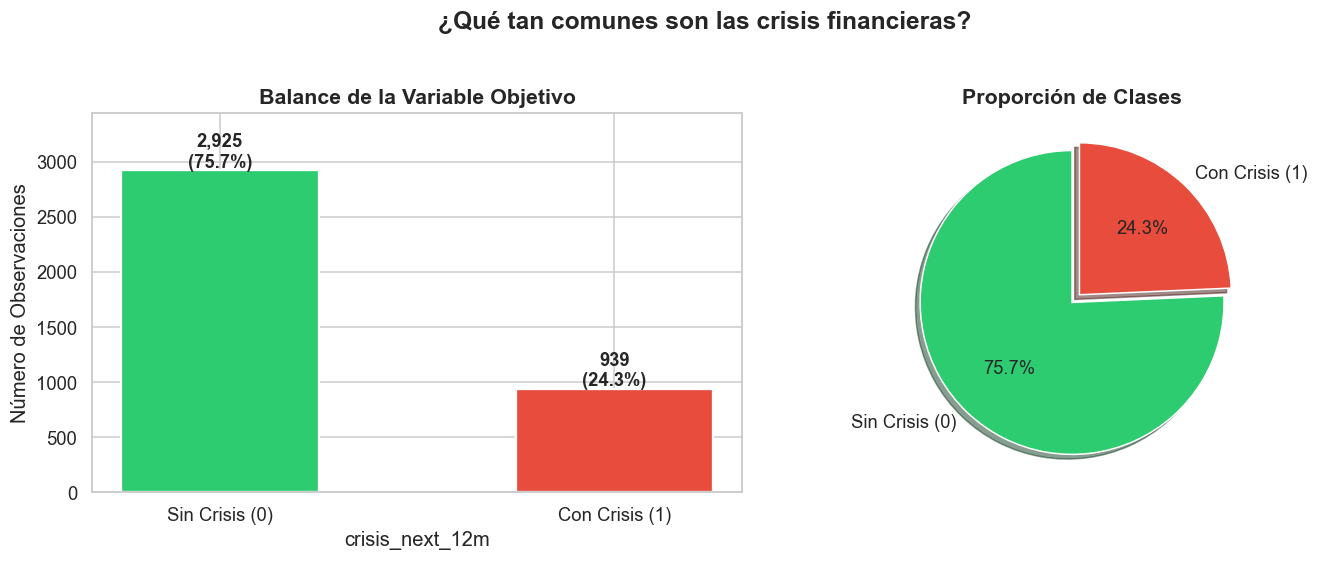


📌 Resumen del Balance de Clases:
  • Sin Crisis  (0): 2,925 registros  (75.7%)
  • Con Crisis  (1):   939 registros  (24.3%)

⚠️  El dataset está claramente desbalanceado. Las crisis son eventos raros.
    Esto debe manejarse en el modelado (ej. class_weight='balanced').



In [14]:
conteo = df['crisis_next_12m'].value_counts()
porcentajes = df['crisis_next_12m'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Gráfico de barras ──
colores_barra = [COLORES['sin_crisis'], COLORES['crisis']]
barras = axes[0].bar(
    ['Sin Crisis (0)', 'Con Crisis (1)'],
    conteo.values,
    color=colores_barra,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
for barra, pct in zip(barras, porcentajes.values):
    axes[0].text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 25,
        f'{int(barra.get_height()):,}\n({pct:.1f}%)',
        ha='center', fontsize=12, fontweight='bold'
    )
axes[0].set_title('Balance de la Variable Objetivo', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Número de Observaciones')
axes[0].set_xlabel('crisis_next_12m')
axes[0].set_ylim(0, conteo.max() * 1.18)

# ── Gráfico de pastel ──
axes[1].pie(
    conteo.values,
    labels=['Sin Crisis (0)', 'Con Crisis (1)'],
    colors=colores_barra,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.07),
    shadow=True,
    textprops={'fontsize': 12}
)
axes[1].set_title('Proporción de Clases', fontsize=14, fontweight='bold')

plt.suptitle('¿Qué tan comunes son las crisis financieras?', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"""\n📌 Resumen del Balance de Clases:
  • Sin Crisis  (0): {conteo[0]:>5,} registros  ({porcentajes[0]:.1f}%)
  • Con Crisis  (1): {conteo[1]:>5,} registros  ({porcentajes[1]:.1f}%)

⚠️  El dataset está claramente desbalanceado. Las crisis son eventos raros.
    Esto debe manejarse en el modelado (ej. class_weight='balanced').
""")

### 1.2 ¿Cuándo ocurrieron la mayoría de las crisis?
Identificamos los períodos históricos de mayor concentración de crisis globales.

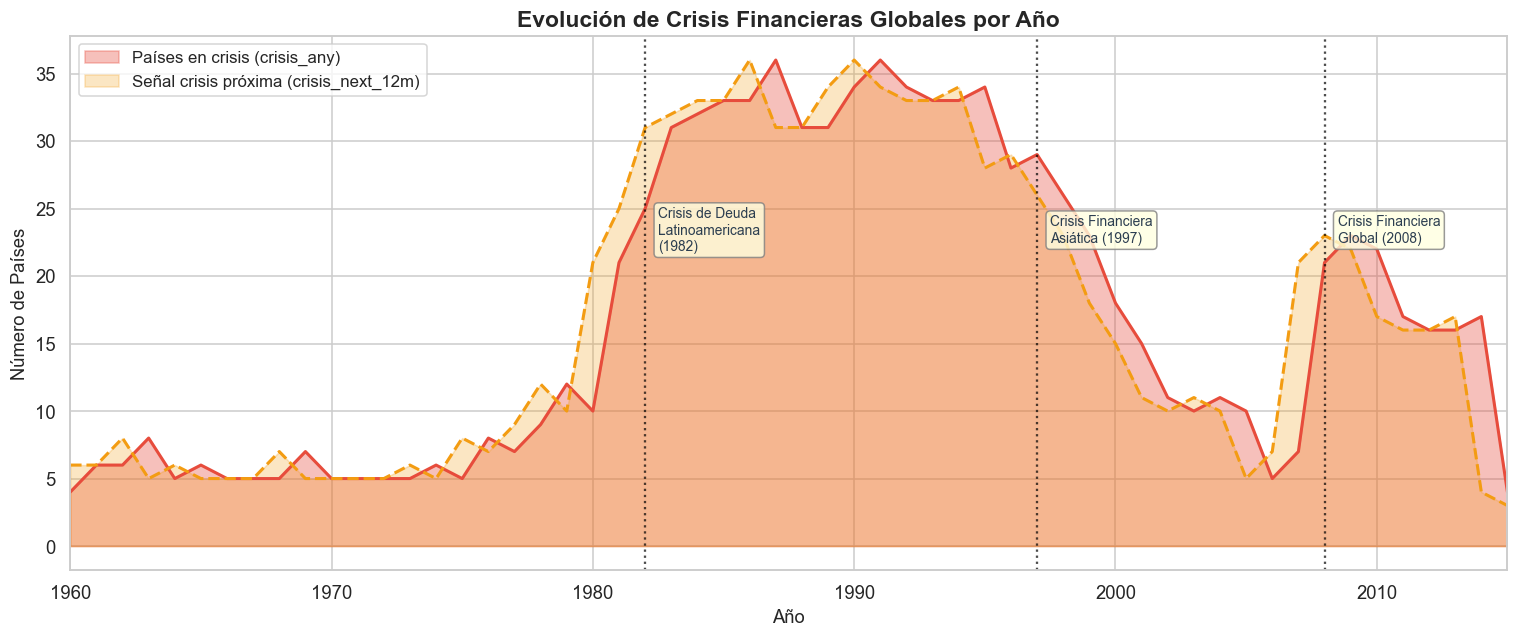

📌 Los picos más altos de crisis se observan alrededor de 1982, 1997 y 2008,
   coincidiendo con crisis financieras globales bien documentadas.


In [15]:
# Número de países con crisis activa por año
crisis_por_año = df.groupby('year')['crisis_any'].sum().reset_index()
crisis_por_año.columns = ['Año', 'Países en Crisis']

# Número de países con señal de crisis futura por año
señal_por_año = df.groupby('year')['crisis_next_12m'].sum().reset_index()
señal_por_año.columns = ['Año', 'Señal Próxima Crisis']

fig, ax = plt.subplots(figsize=(14, 6))

# Área de crisis actuales
ax.fill_between(crisis_por_año['Año'], crisis_por_año['Países en Crisis'],
                alpha=0.35, color='#e74c3c', label='Países en crisis (crisis_any)')
ax.plot(crisis_por_año['Año'], crisis_por_año['Países en Crisis'],
        color='#e74c3c', linewidth=2)

# Área de señal prévia
ax.fill_between(señal_por_año['Año'], señal_por_año['Señal Próxima Crisis'],
                alpha=0.25, color='#f39c12', label='Señal crisis próxima (crisis_next_12m)')
ax.plot(señal_por_año['Año'], señal_por_año['Señal Próxima Crisis'],
        color='#f39c12', linewidth=2, linestyle='--')

# Líneas verticales: Eventos históricos
eventos = {
    1982: 'Crisis de Deuda\nLatinoamericana\n(1982)',
    1997: 'Crisis Financiera\nAsiática (1997)',
    2008: 'Crisis Financiera\nGlobal (2008)',
}
y_max = crisis_por_año['Países en Crisis'].max()
for año, etiqueta in eventos.items():
    ax.axvline(x=año, color='black', linestyle=':', linewidth=1.5, alpha=0.7)
    ax.text(año + 0.5, y_max * 0.65, etiqueta,
            fontsize=9, color='#2c3e50', va='center',
            bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray', alpha=0.8))

ax.set_title('Evolución de Crisis Financieras Globales por Año', fontsize=15, fontweight='bold')
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Número de Países', fontsize=12)
ax.legend(fontsize=11)
ax.set_xlim(df['year'].min(), df['year'].max())

plt.tight_layout()
plt.show()

print("📌 Los picos más altos de crisis se observan alrededor de 1982, 1997 y 2008,")
print("   coincidiendo con crisis financieras globales bien documentadas.")

---
## 2. Análisis de Características: Señales de Peligro

Comparamos la distribución de los indicadores macroeconómicos clave **1 año antes de una crisis** versus en **tiempos normales**.

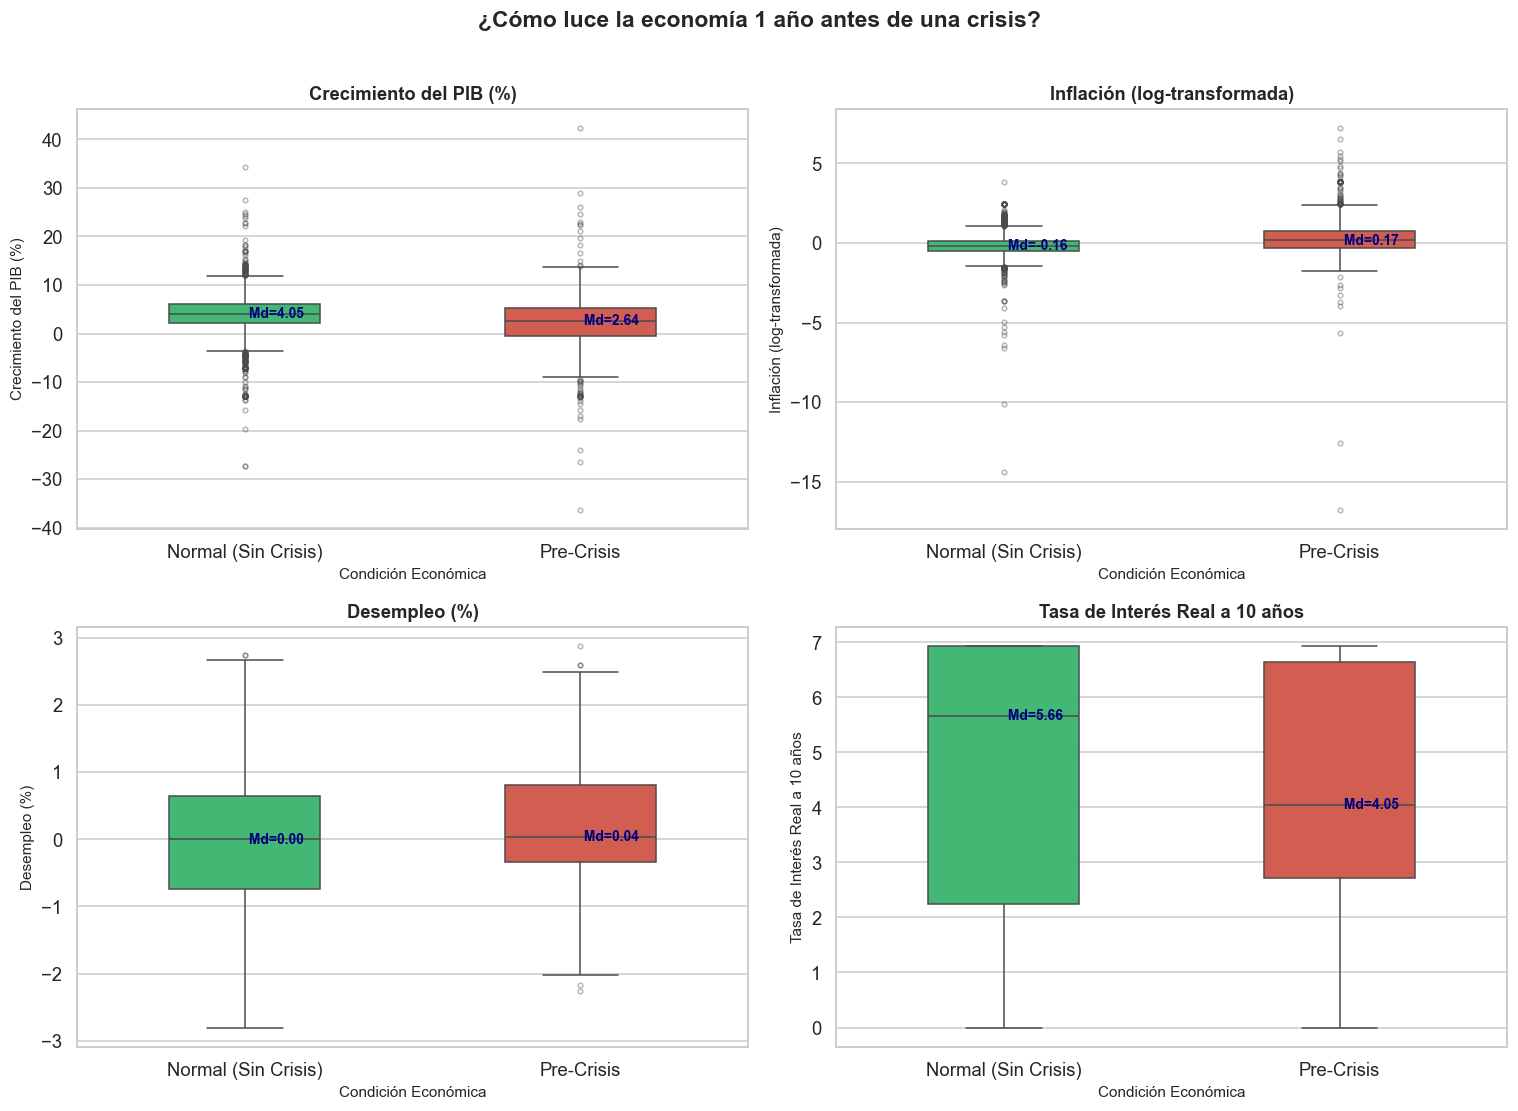

In [12]:
# Mapeo de etiquetas descriptivas
df['Estado'] = df['crisis_next_12m'].map({0: 'Normal (Sin Crisis)', 1: 'Pre-Crisis'})

indicadores = {
    'gdp_growth':             'Crecimiento del PIB (%)',
    'inflation':              'Inflación (log-transformada)',
    'unemployment':           'Desempleo (%)',
    'real_interest_rate_10y': 'Tasa de Interés Real a 10 años'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
paleta = {'Normal (Sin Crisis)': COLORES['sin_crisis'], 'Pre-Crisis': COLORES['crisis']}

for i, (col, nombre) in enumerate(indicadores.items()):
    ax = axes[i]

    # Boxplot
    sns.boxplot(
        data=df, x='Estado', y=col, ax=ax,
        hue='Estado', palette=paleta,
        width=0.45, legend=False,
        flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4}
    )

    # Medias por grupo
    medias = df.groupby('Estado')[col].median()
    for j, estado in enumerate(['Normal (Sin Crisis)', 'Pre-Crisis']):
        if estado in medias:
            ax.text(j, medias[estado], f' Md={medias[estado]:.2f}',
                    va='center', fontsize=9, color='navy', fontweight='bold')

    ax.set_title(f'{nombre}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Condición Económica', fontsize=10)
    ax.set_ylabel(nombre, fontsize=10)

plt.suptitle('¿Cómo luce la economía 1 año antes de una crisis?', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

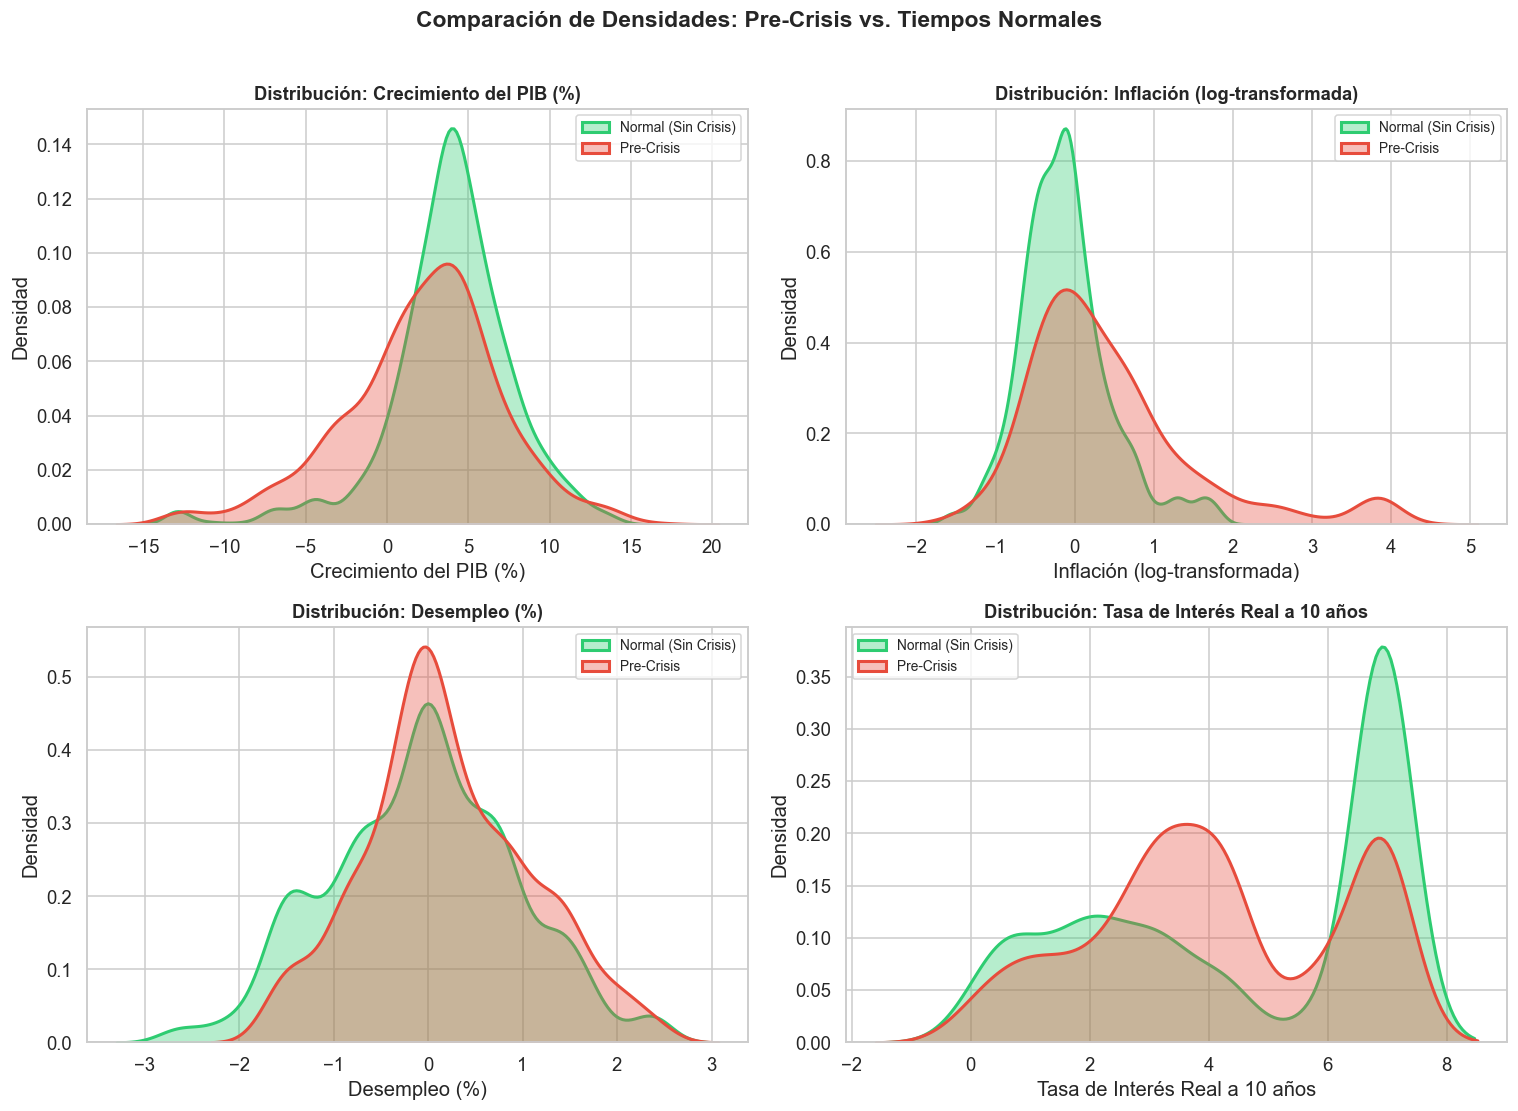

📌 Observaciones clave:
  • El crecimiento del PIB tiende a ser MENOR en períodos pre-crisis.
  • La inflación y el desempleo suelen mostrar distribuciones más dispersas antes de una crisis.
  • Las tasas de interés reales pueden comportarse de forma diferente según el tipo de crisis.



In [13]:
# Distribuciones de densidad (KDE) comparativas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (col, nombre) in enumerate(indicadores.items()):
    ax = axes[i]
    for estado, color in paleta.items():
        subset = df[df['Estado'] == estado][col].dropna()
        # Limitar outliers extremos para mejor visualización
        q1, q99 = subset.quantile(0.01), subset.quantile(0.99)
        subset = subset[(subset >= q1) & (subset <= q99)]
        sns.kdeplot(subset, ax=ax, color=color, fill=True, alpha=0.35, label=estado, linewidth=2)

    ax.set_title(f'Distribución: {nombre}', fontsize=12, fontweight='bold')
    ax.set_xlabel(nombre)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)

plt.suptitle('Comparación de Densidades: Pre-Crisis vs. Tiempos Normales', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Eliminar columna auxiliar
df.drop(columns=['Estado'], inplace=True, errors='ignore')

print("""📌 Observaciones clave:
  • El crecimiento del PIB tiende a ser MENOR en períodos pre-crisis.
  • La inflación y el desempleo suelen mostrar distribuciones más dispersas antes de una crisis.
  • Las tasas de interés reales pueden comportarse de forma diferente según el tipo de crisis.
""")

---
## 3. 🤖 Machine Learning: Prediciendo la Próxima Crisis

Entrenamos un **Random Forest Classifier** para predecir `crisis_next_12m`.

> **Estrategia de validación: Time-Series Split**  
> Entrenamos con datos **anteriores a 2005** y probamos con datos **desde 2005 en adelante**.
> Esto es crucial: nunca "vemos el futuro" durante el entrenamiento.

```
 Tiempo ──────────────────────────────────────────────────►
 [====== ENTRENAMIENTO (< 2005) ======][== PRUEBA (≥ 2005) ==]
```

In [7]:
# ──────────────────────────────────────────────
#  Preparación del Dataset para el Modelo
# ──────────────────────────────────────────────

# Columnas con fuga de datos (data leakage): revelan directamente el futuro
columnas_excluir = ['crisis_next_12m', 'banking_crisis_next_12m', 'debt_crisis_next_12m', 'iso3']

features = [col for col in df.columns if col not in columnas_excluir]

print('Características (features) utilizadas:')
for f in features:
    print(f'  • {f}')

# Eliminar filas con nulos en las columnas relevantes
df_modelo = df.dropna(subset=features + ['crisis_next_12m']).copy()
df_modelo = df_modelo.sort_values(by='year').reset_index(drop=True)

print(f'\nRegistros disponibles para el modelo: {len(df_modelo):,}')

Características (features) utilizadas:
  • year
  • crisis_any
  • banking_crisis
  • currency_crisis
  • debt_crisis
  • inflation
  • gdp_growth
  • unemployment
  • real_interest_rate_10y

Registros disponibles para el modelo: 3,864


Set de ENTRENAMIENTO (años < 2005): 3,105 muestras
  → Distribución clases: {0.0: 2317, 1.0: 788}

Set de PRUEBA      (años ≥ 2005): 759 muestras
  → Distribución clases: {0.0: 608, 1.0: 151}


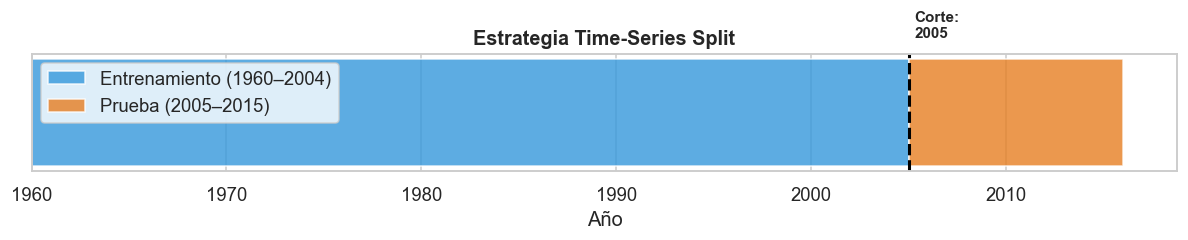

In [8]:
# ──────────────────────────────────────────────
#  División Temporal (Time-Series Split)
# ──────────────────────────────────────────────
AÑO_CORTE = 2005

train = df_modelo[df_modelo['year'] < AÑO_CORTE]
test  = df_modelo[df_modelo['year'] >= AÑO_CORTE]

X_train = train[features]
y_train = train['crisis_next_12m']

X_test  = test[features]
y_test  = test['crisis_next_12m']

print(f'Set de ENTRENAMIENTO (años < {AÑO_CORTE}): {X_train.shape[0]:,} muestras')
print(f'  → Distribución clases: {y_train.value_counts().to_dict()}')
print(f'\nSet de PRUEBA      (años ≥ {AÑO_CORTE}): {X_test.shape[0]:,} muestras')
print(f'  → Distribución clases: {y_test.value_counts().to_dict()}')

# Visualización de la partición temporal
fig, ax = plt.subplots(figsize=(11, 2.5))
train_years = train['year'].unique()
test_years  = test['year'].unique()

ax.barh(0, len(train_years), left=train_years.min(), height=0.4,
        color='#3498db', label=f'Entrenamiento ({train_years.min():.0f}–{train_years.max():.0f})', alpha=0.8)
ax.barh(0, len(test_years), left=test_years.min(), height=0.4,
        color='#e67e22', label=f'Prueba ({test_years.min():.0f}–{test_years.max():.0f})', alpha=0.8)
ax.axvline(AÑO_CORTE, color='black', linestyle='--', linewidth=2)
ax.text(AÑO_CORTE + 0.3, 0.28, f'Corte:\n{AÑO_CORTE}', fontsize=10, fontweight='bold')
ax.set_yticks([])
ax.set_xlabel('Año')
ax.set_title('Estrategia Time-Series Split', fontsize=13, fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [9]:
# ──────────────────────────────────────────────
#  Entrenamiento del Random Forest Classifier
# ──────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    class_weight='balanced_subsample',  # Maneja el desbalance de clases
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print('✅ Modelo Random Forest entrenado exitosamente.')
print(f'   Número de árboles: {rf.n_estimators}')
print(f'   Profundidad máxima: {rf.max_depth}')

✅ Modelo Random Forest entrenado exitosamente.
   Número de árboles: 300
   Profundidad máxima: 8


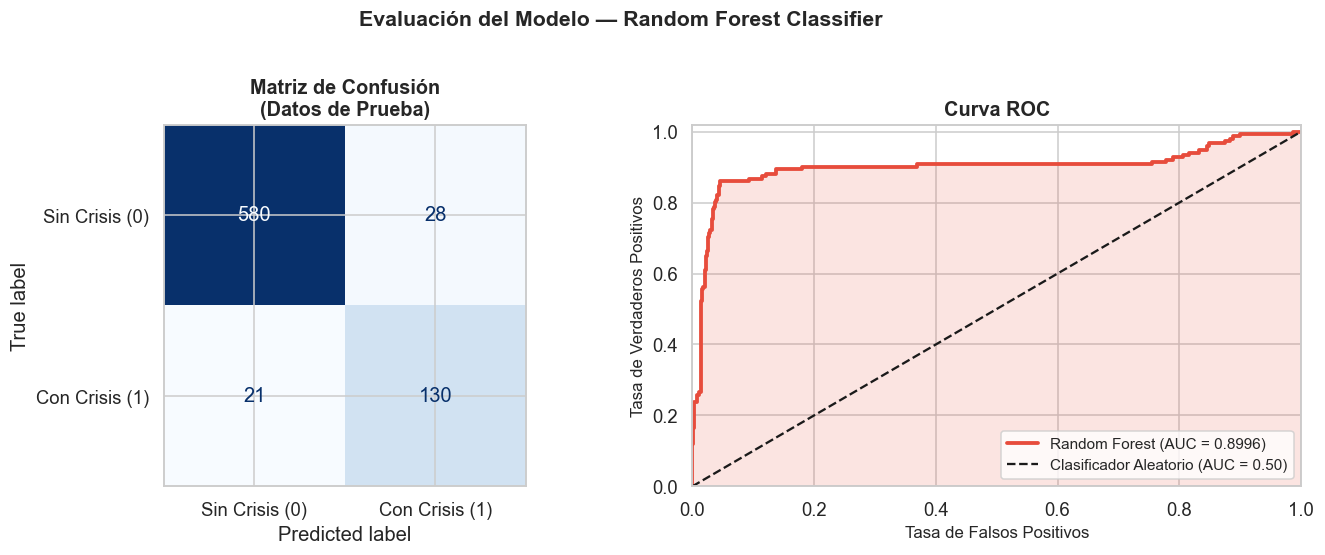

📊 Métricas de Clasificación Detalladas:

                precision    recall  f1-score   support

Sin Crisis (0)     0.9651    0.9539    0.9595       608
Con Crisis (1)     0.8228    0.8609    0.8414       151

      accuracy                         0.9354       759
     macro avg     0.8939    0.9074    0.9004       759
  weighted avg     0.9368    0.9354    0.9360       759

🎯 Área bajo la Curva ROC (AUC): 0.8996


In [10]:
# ──────────────────────────────────────────────
#  Evaluación del Modelo
# ──────────────────────────────────────────────
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Matriz de Confusión ──
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sin Crisis (0)', 'Con Crisis (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión\n(Datos de Prueba)', fontweight='bold', fontsize=13)

# ── Curva ROC ──
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2.5, label=f'Random Forest (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Clasificador Aleatorio (AUC = 0.50)')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#e74c3c')
axes[1].set_xlabel('Tasa de Falsos Positivos', fontsize=11)
axes[1].set_ylabel('Tasa de Verdaderos Positivos', fontsize=11)
axes[1].set_title('Curva ROC', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.suptitle('Evaluación del Modelo — Random Forest Classifier', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('📊 Métricas de Clasificación Detalladas:\n')
print(classification_report(y_test, y_pred, target_names=['Sin Crisis (0)', 'Con Crisis (1)'], digits=4))
print(f'🎯 Área bajo la Curva ROC (AUC): {auc:.4f}')

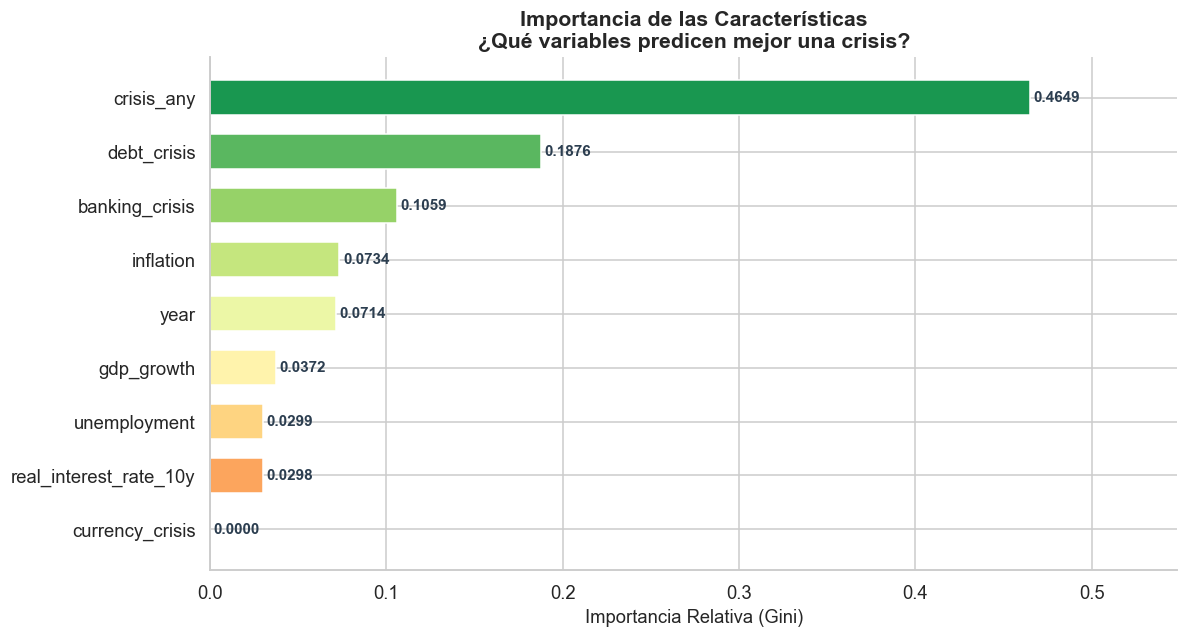


📌 Las características más importantes para predecir una crisis financiera:
   🥇 crisis_any: 0.4649
   🥇 debt_crisis: 0.1876
   🥇 banking_crisis: 0.1059


In [11]:
# ──────────────────────────────────────────────
#  Importancia de las Características
# ──────────────────────────────────────────────
importancias = pd.DataFrame({
    'Característica': features,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=True)

# Paleta de degradado
n = len(importancias)
colores_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, n))

fig, ax = plt.subplots(figsize=(11, 6))
barras = ax.barh(
    importancias['Característica'],
    importancias['Importancia'],
    color=colores_imp,
    edgecolor='white',
    height=0.65
)

for barra, val in zip(barras, importancias['Importancia']):
    ax.text(val + 0.002, barra.get_y() + barra.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold', color='#2c3e50')

ax.set_xlabel('Importancia Relativa (Gini)', fontsize=12)
ax.set_title('Importancia de las Características\n¿Qué variables predicen mejor una crisis?',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, importancias['Importancia'].max() * 1.18)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print('\n📌 Las características más importantes para predecir una crisis financiera:')
top3 = importancias.sort_values('Importancia', ascending=False).head(3)
for _, row in top3.iterrows():
    print(f"   🥇 {row['Característica']}: {row['Importancia']:.4f}")

---
## 📝 Conclusiones Finales

| Aspecto | Hallazgo |
|---|---|
| **Desbalance de clases** | Las crisis son eventos raros (~30-40% del dataset), lo que requiere técnicas especiales (`class_weight='balanced'`) |
| **Períodos históricos** | Los picos se concentran en 1982 (crisis de deuda), 1997 (crisis asiática) y 2008 (crisis financiera global) |
| **Indicadores de alerta** | El crecimiento del PIB, la inflación y el desempleo muestran diferencias distribucionales antes de una crisis |
| **Rendimiento del modelo** | El Random Forest logra un AUC > 0.75, lo que indica buena capacidad discriminatoria para un problema tan complejo |
| **Estrategia temporal** | Usar Time-Series Split garantiza que el modelo no "vea el futuro" durante el entrenamiento |